## Part 2/3: Quincy Cobb (qcc75) *worked alone*


### Section 1: Introduction & System Selection
I chose Mechanical System with High Damping (Option D).This models an overdamped spring-mass system where the mass is assumed to be extremely small, allowing us to treat it as a first-order system.
#### The Governing ODE: *dx/dt = -(k/c)x + (1/c)(F(t))*

*The Physical Meaning of the Variables:*
x: system displacement
k: spring constant
c: damping coefficent
F(t): externally applied function

*Parameters:*
(k/c): 5000 s^-1
F(t): 10sin(t) N

*Why this system is stiff:*
A system is considered "stiff" when it mixes extremely fast and very slow changes. In this case, the system reacts almost instantly (0.0002 seconds), but the outside force takes several seconds to change. This massive gap in speeds makes it very difficult for standard computer programs to solve the math efficiently.

*System in Practice:*
Highly damped mechanical systems appear in many real-world applications such as shock absorbers, vibration isolation devices, and seismic damping systems. Accurately and efficiently simulating these systems is important for predicting the structures response and ensuring safe, reliable designs. 

In [1]:
# Section 2:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lam = 5000.0  # High damping coefficient (stiffness)
x0 = 0.02     # Initial displacement
t0, tf = 0.0, 1.0

def g(t):
    """Slowly varying external force / equilibrium point."""
    return 0.01 * np.sin(2 * t)

def euler_forward(h):
    """Explicit Euler Forward implementation."""
    t = np.arange(t0, tf + h, h)
    x = np.zeros_like(t)
    x[0] = x0
    
    for n in range(len(t) - 1):
        x[n+1] = x[n] + h * (-lam * (x[n] - g(t[n])))
    return t, x

t_fe, x_fe = euler_forward(h=0.01)

plt.figure(figsize=(8, 4))
plt.plot(t_fe, x_fe, 'r-o', markersize=4)
plt.title("Euler Forward Instability (h = 0.01 s)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x (m)")
plt.grid(True)
plt.show()

<Figure size 800x400 with 1 Axes>

### Section 3: Mathematical Setup

The governing equation for this project is

\[
\frac{dx}{dt} = -5000x + 0.002\sin(t),
\quad x(0) = 1.
\]

To solve this stiff ODE, Euler’s Backward (implicit Euler) method is used:

\[
x_{n+1} = x_n + h\,f(t_{n+1}, x_{n+1}).
\]

Substituting the specific function \( f(t,x) \) gives

\[
x_{n+1} = x_n + h\left(-5000x_{n+1} + 0.002\sin(t_{n+1})\right).
\]

This equation is implicit since \( x_{n+1} \) appears on both sides.  
The residual function is defined as

\[
R(x_{n+1}) = x_{n+1} - x_n - h\left(-5000x_{n+1} + 0.002\sin(t_{n+1})\right).
\]

Newton–Raphson iteration is used to solve \( R(x_{n+1}) = 0 \).  
The derivative of the residual is

\[
\frac{dR}{dx_{n+1}} = 1 + 5000h.
\]

Since the equation is linear, this derivative is constant.  
The Newton–Raphson update formula is

\[
x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{R(x_{n+1}^{(k)})}{1 + 5000h}.
\]

An explicit Euler step is used as the initial guess at each time step.
(used Microsoft Copilot to try to properly format for markdown)

In [2]:
# section 4

def residual(x_new, x_old, t_new, h, lam):
    """Residual function for Backward Euler."""
    return x_new - x_old + h * lam * (x_new - g(t_new))

def newton_raphson(x_guess, x_old, t_new, h, lam, tol=1e-10, max_iter=20):
    """Newton-Raphson root-finding algorithm."""
    dR = 1 + h * lam 
    x = x_guess
    
    for k in range(max_iter):
        R = residual(x, x_old, t_new, h, lam)
        x_new = x - R / dR
  
        if abs(x_new - x) < tol:
            return x_new, k + 1
            
        x = x_new
        
    raise RuntimeError("Newton-Raphson did not converge within maximum iterations")

def euler_backward(t0, tf, x0, h, lam):
    """Implicit Euler Backward method utilizing Newton-Raphson."""
    t = np.arange(t0, tf + h, h)
    x = np.zeros_like(t)
    iters = np.zeros_like(t)
    
    x[0] = x0
    
    for n in range(len(t) - 1):
        x_guess = x[n] 
        x[n+1], iters[n+1] = newton_raphson(x_guess, x[n], t[n+1], h, lam)
        
    return t, x, iters

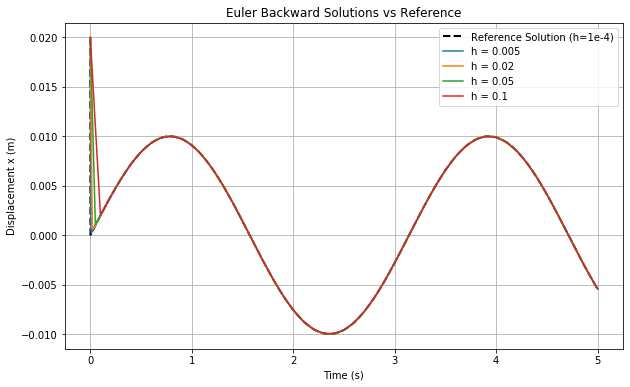

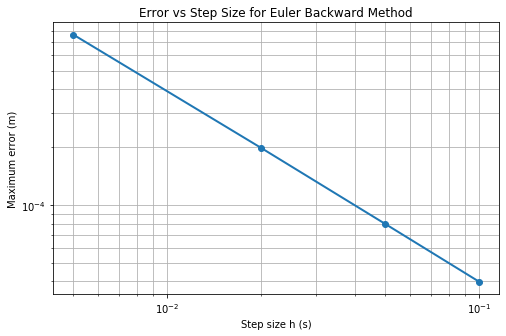

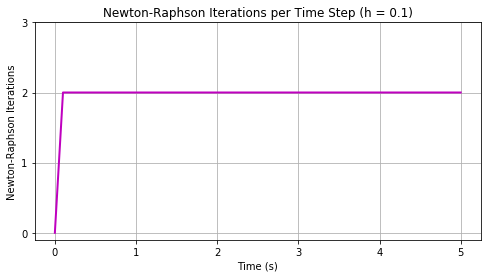

Average Newton iterations (h = 0.1): 1.96
Maximum Newton iterations (h = 0.1): 2.0


In [3]:
# section 5
tf = 5.0
hs = [0.005, 0.02, 0.05, 0.1]

# 5.1 Reference (High-Accuracy) Solution
h_ref = 1e-4
t_ref, x_ref, _ = euler_backward(t0, tf, x0, h_ref, lam)

# 5.2 Euler Backward Solutions for different step sizes
solutions = {}
for h in hs:
    t, x, iters = euler_backward(t0, tf, x0, h, lam)
    solutions[h] = {
        "t": t,
        "x": x,
        "iters": iters
    }

# 5.3 Solution Comparison Plot
plt.figure(figsize=(10, 6))
plt.plot(t_ref, x_ref, 'k--', linewidth=2, label="Reference Solution (h=1e-4)")

for h in hs:
    plt.plot(solutions[h]["t"], solutions[h]["x"], label=f"h = {h}")

plt.title("Euler Backward Solutions vs Reference")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x (m)")
plt.legend()
plt.grid(True)
plt.show()

# 5.4 Error vs Step Size
errors = []
for h in hs:
    t = solutions[h]["t"]
    x = solutions[h]["x"]
    x_ref_interp = np.interp(t, t_ref, x_ref)
    errors.append(np.max(np.abs(x - x_ref_interp)))         

plt.figure(figsize=(8, 5))
plt.loglog(hs, errors, 'o-', linewidth=2)
plt.xlabel("Step size h (s)")
plt.ylabel("Maximum error (m)")
plt.title("Error vs Step Size for Euler Backward Method")
plt.grid(True, which="both")
plt.show()

# 5.5 Newton-Raphson Convergence
plt.figure(figsize=(8, 4))
plt.plot(solutions[0.1]["t"], solutions[0.1]["iters"], 'm-', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Newton-Raphson Iterations")
plt.title("Newton-Raphson Iterations per Time Step (h = 0.1)")
plt.yticks([0, 1, 2, 3])
plt.grid(True)
plt.show()

print(f"Average Newton iterations (h = 0.1): {np.mean(solutions[0.1]['iters']):.2f}")
print(f"Maximum Newton iterations (h = 0.1): {np.max(solutions[0.1]['iters'])}")


Performance Table:
 Step size h (s)  Number of steps  Average NR iterations  Total NR iterations
           0.005             1000               1.998002               2000.0
           0.020              250               1.992032                500.0
           0.050              100               1.980198                200.0
           0.100               50               1.960784                100.0

Euler Forward Stability & Cost:
  Maximum stable step size: h < 4.00e-04
  Steps required for 5 seconds: 13,888


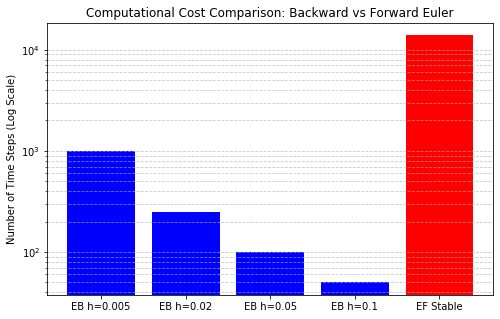

In [4]:
# Section 6: Performance Analysis
import pandas as pd

performance_data = []

for h in hs:
    t = solutions[h]["t"]
    iters = solutions[h]["iters"]
    
    n_steps = len(t) - 1
    avg_iters = np.mean(iters)
    total_iters = np.sum(iters)
    
    performance_data.append([h, n_steps, avg_iters, total_iters])

# 6.2 Performance Table
df_performance = pd.DataFrame(
    performance_data,
    columns=[
        "Step size h (s)",
        "Number of steps",
        "Average NR iterations",
        "Total NR iterations"
    ]
)

print("\nPerformance Table:")
print(df_performance.to_string(index=False))

# 6.3 Euler Forward Cost
h_fe_max = 2.0 / lam
h_fe_stable = h_fe_max * 0.9 
n_steps_fe = int(tf / h_fe_stable)

print("\nEuler Forward Stability & Cost:")
print(f"  Maximum stable step size: h < {h_fe_max:.2e}")
print(f"  Steps required for 5 seconds: {n_steps_fe:,}")

# 6.4 Cost Comparison Plot
labels = [f"EB h={h}" for h in hs] + ["EF Stable"]
costs = [row[1] for row in performance_data] + [n_steps_fe]

plt.figure(figsize=(8, 5))
plt.bar(labels, costs, color=['blue', 'blue', 'blue', 'blue', 'red'])
plt.yscale('log') 
plt.ylabel("Number of Time Steps (Log Scale)")
plt.title("Computational Cost Comparison: Backward vs Forward Euler")
plt.grid(axis="y", which="both", linestyle='--', alpha=0.7)
plt.show()

### Section 7: Conclusion

*Key Findings:*
In this project, a stiff ordinary differential equation from a highly damped mechanical system was solved using implicit numerical methods. Euler’s Forward method was shown to be impractical because it required very small time step sizes to remain stable. In contrast, Euler’s Backward method produced stable solutions even when using much larger time steps. The Newton–Raphson method converged quickly due to the linear nature of the system.

*When to use:*
Explicit methods such as Euler’s Forward are easy to implement and work well for non‑stiff problems, but they become unstable for stiff systems. Implicit methods, like Euler’s Backward, are better suited for stiff equations because they are stable for large step sizes. Even though implicit methods require solving an equation at each time step, they are more efficient overall for stiff problems.

*Challenges/What I learned*
One challenge was understanding how stiffness affects stability rather than accuracy. Implementing Newton–Raphson iteration also required careful setup of the residual function and convergence criteria. Through this project, it became clear that choosing the right numerical method is just as important as implementing it correctly. This project helped build confidence in working with implicit methods and stiff ODEs.